# Goal:
In the previous notebook `1q_random_init_vs_sequences.ipynb` we were able to observe a good phase transition that agrees with what we would expect! 

Here, we want to change the rank of the Kraus operator to verify that our predictions still agree with the numerical results. 

Once again, fingers crossed 🤞.

Date of creation: 07.08.2026

In [1]:
from mGST.utility_functions_comparisons import get_target_operators_gate_set_name, get_compressed_rep_from_mgst_output, kraus_tensor_to_mgst, get_initial_gate_set_for_optimization, get_mgst_tensors_from_psd_representation
from mGST.simulate import apply_noisy_kraus_tensors_to_target_gate_set, get_random_noisy_kraus_tensors_for_gate_set, get_random_gate_set_superop, generate_sequence_indices, run_optimization_workflow, run_optimization_workflow_multi_init, run_optimization_workflow_multi_init_realizations
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.visualization import plot_cost_function, plot_many_mean_std_vs_x
from mGST.analysis import compute_mve_and_wve_for_all_realizations, compute_avg_and_std_along_keys, get_all_realizations_for_key, combine_error_results, save_optimization_result, save_variational_errors
from mGST.gauge_analysis import max_num_parameters, min_num_parameters

import jax.numpy as jnp
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [104]:
num_shots = 1000
num_qubits = 1
dim = 2 ** num_qubits
state_rank = dim # max
povm_rank = dim # max
kraus_rank = 1
noisy_kraus_rank = 1
num_gates = 3
num_povm = dim
gate_set_name = "1QXYI"
noise_strength = 5e-3

In [105]:
# under these parameter, these are the min an max number of parameters based on gauge considerations.
min_expected, max_expected = min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, state_rank=state_rank, povm_rank=povm_rank, kraus_rank=kraus_rank), max_num_parameters(num_qubits=num_qubits, num_gates=num_gates, state_rank=state_rank, povm_rank=povm_rank, kraus_rank=kraus_rank)
print(f"Min expected parameters: {min_expected}, Max expected parameters: {max_expected}")

Min expected parameters: 12, Max expected parameters: 31


# Noiseless and noisy tensors

In [106]:
target_operators, gate_labels = get_target_operators_gate_set_name(gate_set_name=gate_set_name)

In [108]:
random_kraus_tensors = get_random_noisy_kraus_tensors_for_gate_set(
    num_gates=num_gates,
    dim=dim,
    rank_kraus=noisy_kraus_rank, # we don't want to use a unitary noise model, so we instead use rank 2. This also somehow tests the out-of-distribution capabilities of the optimization workflow.
    noise_strength=noise_strength,
    seed=42
)

In [109]:
random_kraus_tensors["kraus"].shape

(3, 1, 2, 2)

In [110]:
noisy_gate_set_superop = apply_noisy_kraus_tensors_to_target_gate_set(
    kraus_tensors_noisy=random_kraus_tensors,
    target_gate_set=target_operators,
    is_target_vectorized=True,
)

kraus_tensor_noisy, povm_psd_noisy, state_psd_noisy = get_compressed_rep_from_mgst_output(*noisy_gate_set_superop.values(), kraus_rank=noisy_kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

In [111]:
# checking what is the rank of the noisy quantum channel
from mGST.utility_functions_comparisons import compute_rank_of_channel

compute_rank_of_channel(noisy_gate_set_superop["kraus"][0])

Array(1, dtype=int64)

In [112]:
# let's get the remaining PSD representations
kraus_target_superop = kraus_tensor_to_mgst(target_operators["kraus"])
# 1. Target
target_gate_set_superops = {
    "kraus": kraus_target_superop,
    "povm": target_operators["povm"],
    "state": target_operators["state"],
}

# Gathering them all in one place
noisy_gate_set_psd = {
    "kraus": kraus_tensor_noisy,
    "povm": povm_psd_noisy,
    "state": state_psd_noisy,
}

In [113]:
[op.shape for op in noisy_gate_set_psd.values()], [op.shape for op in noisy_gate_set_superop.values()]

([(3, 1, 2, 2), (2, 2, 2), (2, 2)], [(3, 4, 4), (2, 4), (4,)])

# Optimization

In [114]:
num_iterations_outer = 20
num_iterations_tr = 5
num_iterations_cg = 10 
tol_grad = 1e-8 # it was 1e-4 before. 1e-8 is suggested in the book.
relative_precision = 1e-11 # decrease by 2 orders of magnitude.
global_gradient_norm_tol = 1e-10 #

tr_schedule_silence = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=False, verbose_cg=False, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad))


optimization_schedule_silence= {
    "kraus": tr_schedule_silence,
    "povm": tr_schedule_silence,
    "state": tr_schedule_silence
}

optimization_options_multi_realizations = {
    "schedule": optimization_schedule_silence,
    "num_iterations_outer": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_gradient_norm_tol,
    "noise_threshold": None,
    "compute_least_squares": True,
    "optimization_verbose": False,
}

num_realizations = 5
num_max_iterations_random_inits = 5
num_max_random_inits = 10
threshold_multiplier = 3.0

optimization_options_multi_realizations

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-11,
 'global_gradient_norm_tol': 1e-10,

# Random-multi init worfklow

In [36]:
num_sequences_small = [10, 20, 30]
batch_size_small = [10, 20, 30]

num_sequences_medium = [40, 50, 60]
batch_size_medium = 0.5

In [10]:
final_results_small, partial_results_small = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=num_sequences_small,
    num_realizations=num_realizations,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=batch_size_small,
    threshold_multiplier=threshold_multiplier,
    # seed=42,        # omit for fully random
    debug=True,     # also captures partial results
)

🔁 Realization 1/5
  📊 num_sequences=10
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 2/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 3/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 4/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 5/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reas

In [30]:
batch_size_small_v2 = 0.5

In [69]:
final_results_small_batched, partial_results_small_batched = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=num_sequences_small,
    num_realizations=num_realizations,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=batch_size_small_v2,
    threshold_multiplier=threshold_multiplier,
    # seed=42,        # omit for fully random
    debug=True,     # also captures partial results
)

🔁 Realization 1/5
  📊 num_sequences=10
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 1/5 ‼️ 
 Reason: Cost function value for State below noise threshold 5.99e-04 📶.
✅ Converged below noise threshold after 1 random initializations. 
 Rnd. Init: Initial cost fn values: {'main': Array(0.02654867, dtype=float64)} 
 Rnd. Init: Final cost fn values: {'main': Array(0.0002037, dtype=float64)}
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 20/20 ‼️ 
 Reason: No convergence criteria met yet ⏳.
  📊 num_sequences=20
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 4/5 ‼️ 
 Reason: Cost function value for Kraus below noise threshold 4.12e-04 📶.
✅ Converged below noise threshold after 1 random initializations. 
 Rnd. Init: Initial cost fn values: {'main': Array(0.04953

In [115]:
final_results_small_noisy_rank_1, partial_results_small_noisy_rank_1 = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=num_sequences_small,
    num_realizations=num_realizations,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=[5, 10, 20],
    threshold_multiplier=threshold_multiplier,
    debug=True,     # also captures partial results
)

🔁 Realization 1/5
  📊 num_sequences=10
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: Cost function value for Povm below noise threshold 3.74e-04 📶.
✅ Converged below noise threshold after 1 random initializations. 
 Rnd. Init: Initial cost fn values: {'main': Array(0.13391356, dtype=float64)} 
 Rnd. Init: Final cost fn values: {'main': Array(0.00035759, dtype=float64)}
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 14/20 ‼️ 
 Reason: Relative change in cost function value 3.87e-12 below target relative precision 1.00e-11 🎯.
  📊 num_sequences=20
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 2/10 🎲👾
🔰 Starting Riemannian Optimiz

In [44]:
final_results_medium, partial_results_medium = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=num_sequences_medium,
    num_realizations=num_realizations,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=batch_size_medium,
    threshold_multiplier=threshold_multiplier,
    # seed=42,        # omit for fully random
    debug=True,     # also captures partial results
)

🔁 Realization 1/5
  📊 num_sequences=40
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 4/5 ‼️ 
 Reason: Norms of all gradients below threshold 1.00e-10 📐.
🎲👾 Running optimization workflow with random initialization 2/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 4/5 ‼️ 
 Reason: Norms of all gradients below threshold 1.00e-10 📐.
🎲👾 Running optimization workflow with random initialization 3/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 4/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 5/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization fin

## MVE

In [11]:
mve_seq_length = 10
num_circuits_sampled = int(1e3)
num_random_runs = 10

In [12]:
# compute the MVE to see if the behaviour that we expected is observed
mve_results_small, wve_results_small = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_results_small,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

In [ ]:
# mve_results_small_batched, wve_results_small_batched = compute_mve_and_wve_for_all_realizations(
#     optimization_results=final_results_small_batched,
#     true_superops=noisy_gate_set_superop,
#     sequence_length=mve_seq_length,
#     num_circuits_sampled=num_circuits_sampled,
#     num_repetitions=num_random_runs,
#     which_data="optimized_operators",
# )

In [70]:
mve_results_small_batched_v2, wve_results_small_batched_v2 = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_results_small_batched,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

In [ ]:
mve_medium, wve_medium = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_results_medium,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

In [116]:
mve_small_rank_1, wve_medium_small_rank_1 = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_results_small_noisy_rank_1,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

In [47]:
mve_combined = combine_error_results(mve_results_small, mve_medium)
mean_mve_results_combined = compute_avg_and_std_along_keys(list_of_errors=mve_combined)

In [71]:
mve_combined_batched = combine_error_results(mve_results_small_batched_v2, mve_medium)
mean_mve_results_combined_batched = compute_avg_and_std_along_keys(list_of_errors=mve_combined_batched)

In [117]:
mve_rank_1 = combine_error_results(mve_small_rank_1)
mean_mve_rank_1 = compute_avg_and_std_along_keys(list_of_errors=mve_rank_1)

In [84]:
get_all_realizations_for_key(mve_results_small_batched_v2, str(20))

[{'mean': Array(0.32419858, dtype=float64),
  'std': Array(0.00547696, dtype=float64)},
 {'mean': Array(0.2698112, dtype=float64),
  'std': Array(0.00627138, dtype=float64)},
 {'mean': Array(0.00552575, dtype=float64),
  'std': Array(9.72805274e-05, dtype=float64)},
 {'mean': Array(0.29517192, dtype=float64),
  'std': Array(0.00551911, dtype=float64)},
 {'mean': Array(0.33699248, dtype=float64),
  'std': Array(0.00958448, dtype=float64)}]

## Visualization

In [14]:
title_init = rf"{num_qubits}Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Random Noisy Gate Set | Shots: {num_shots}"

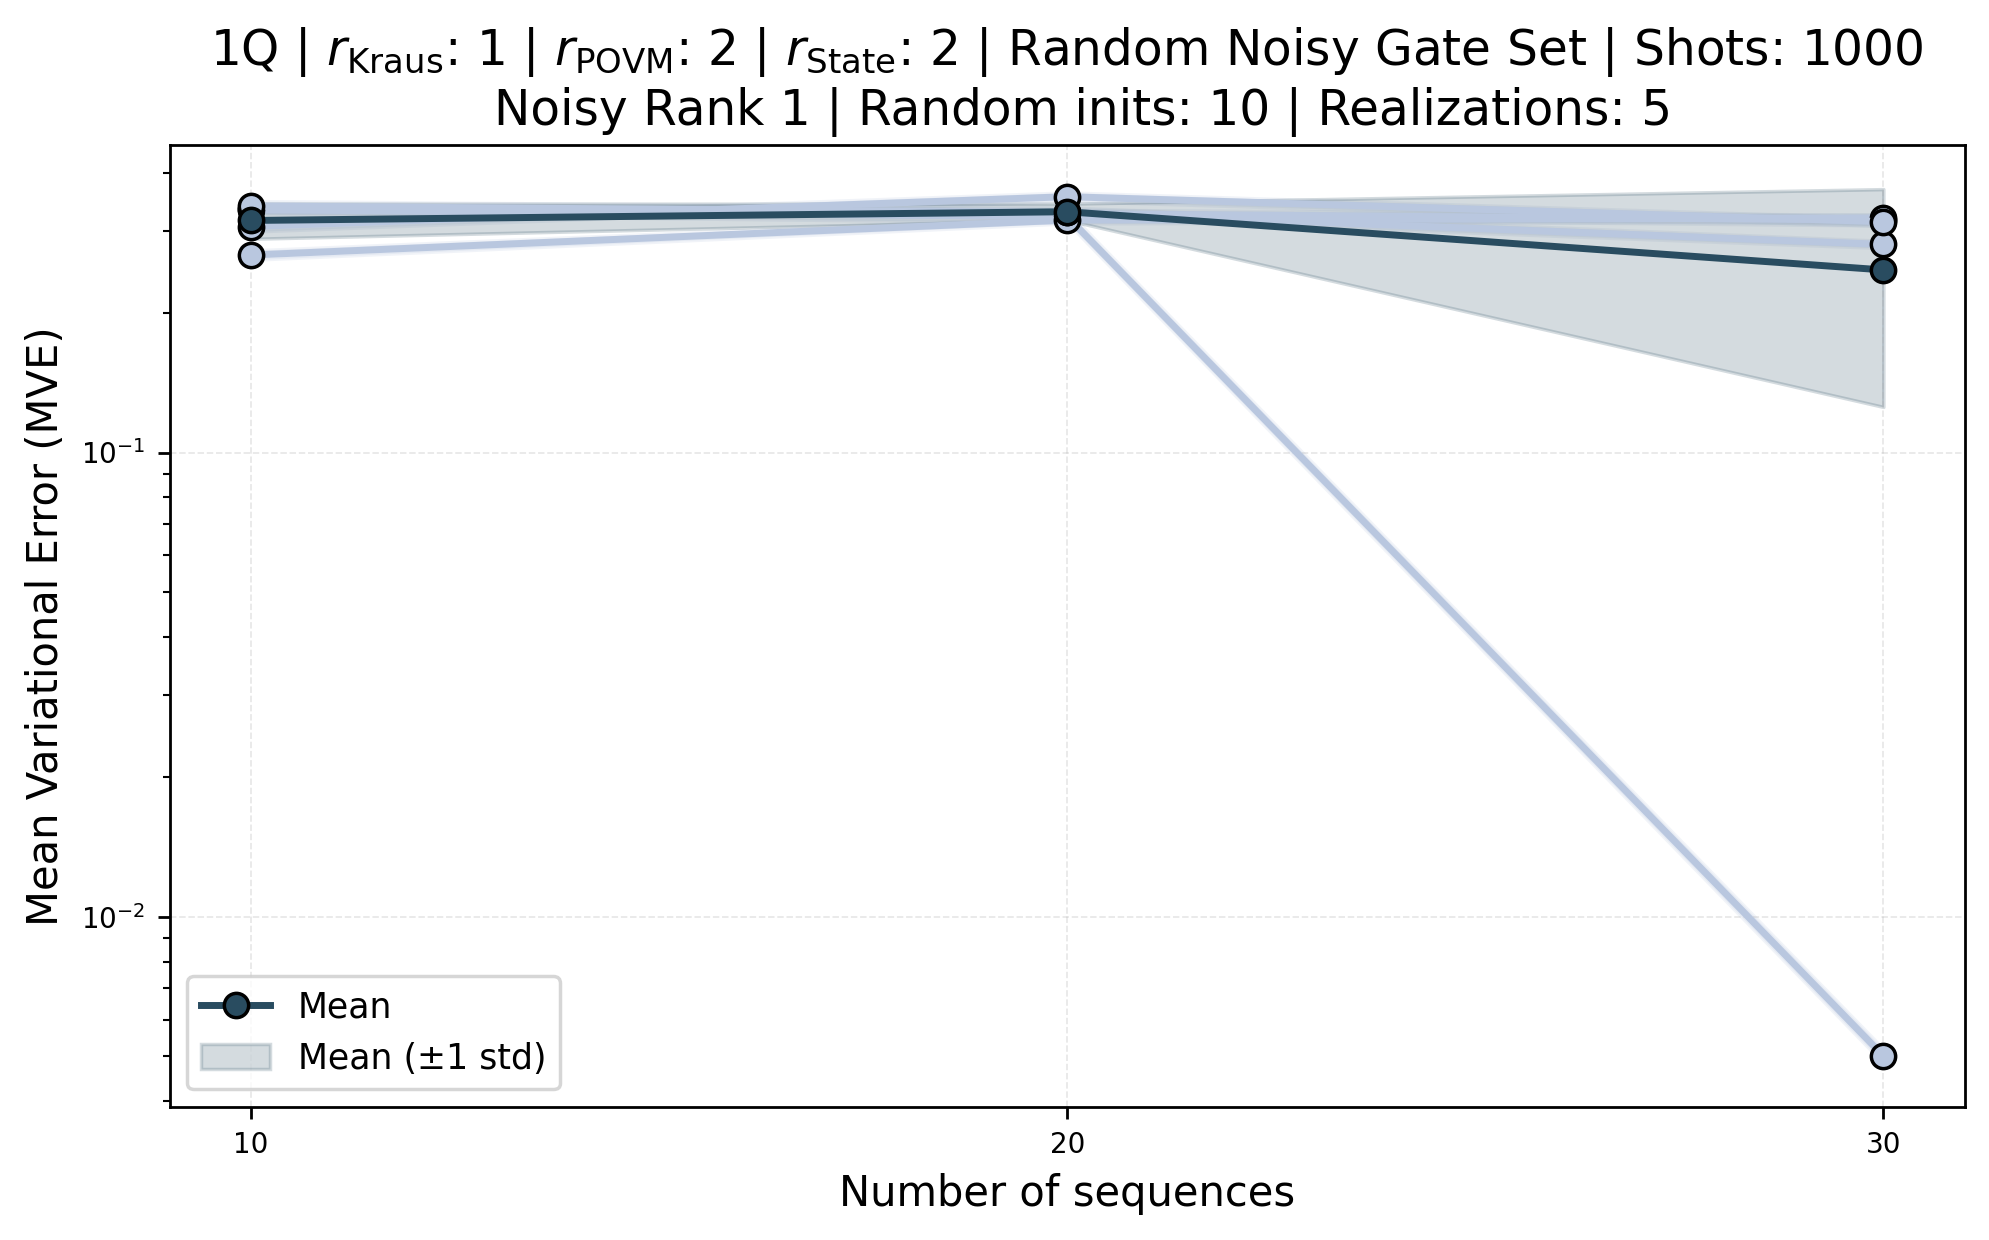

In [120]:
fig_rank_1 = plot_many_mean_std_vs_x(
    data=mve_rank_1,
    title=title_init + f"\n  Noisy Rank {noisy_kraus_rank} | Random inits: {num_max_random_inits} | Realizations: {num_realizations}",
    ylabel=f"Mean Variational Error (MVE)",
    use_log_scale="y",
    main_curve=mean_mve_rank_1,
    main_curve_label="Mean",
)

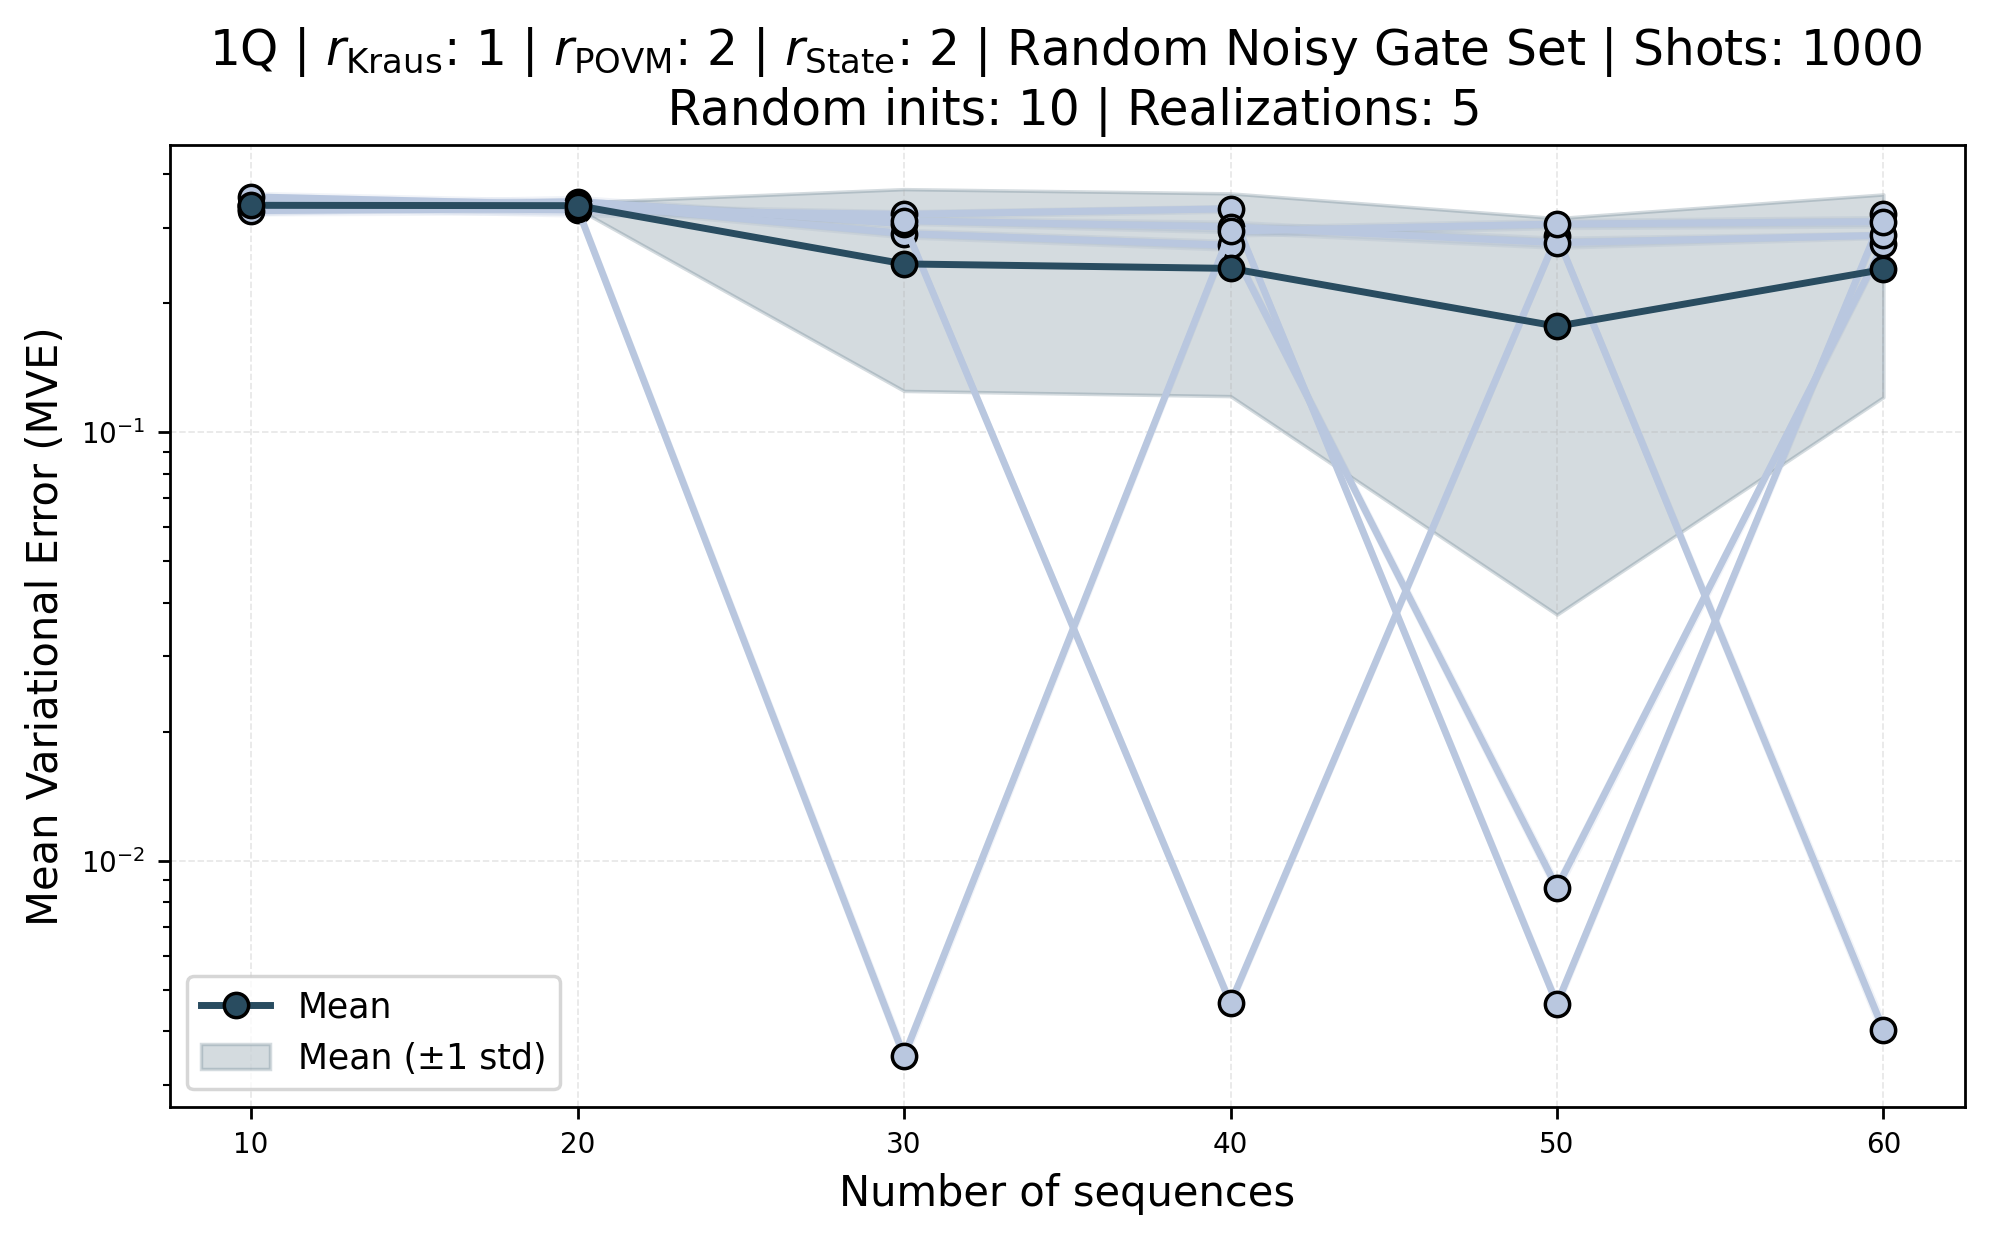

In [49]:
fig_all_mve = plot_many_mean_std_vs_x(
    data=mve_combined,
    title=title_init + f" \n Random inits: {num_max_random_inits} | Realizations: {num_realizations}",
    ylabel=f"Mean Variational Error (MVE)",
    use_log_scale="y",
    main_curve=mean_mve_results_combined,
    main_curve_label="Mean",
)

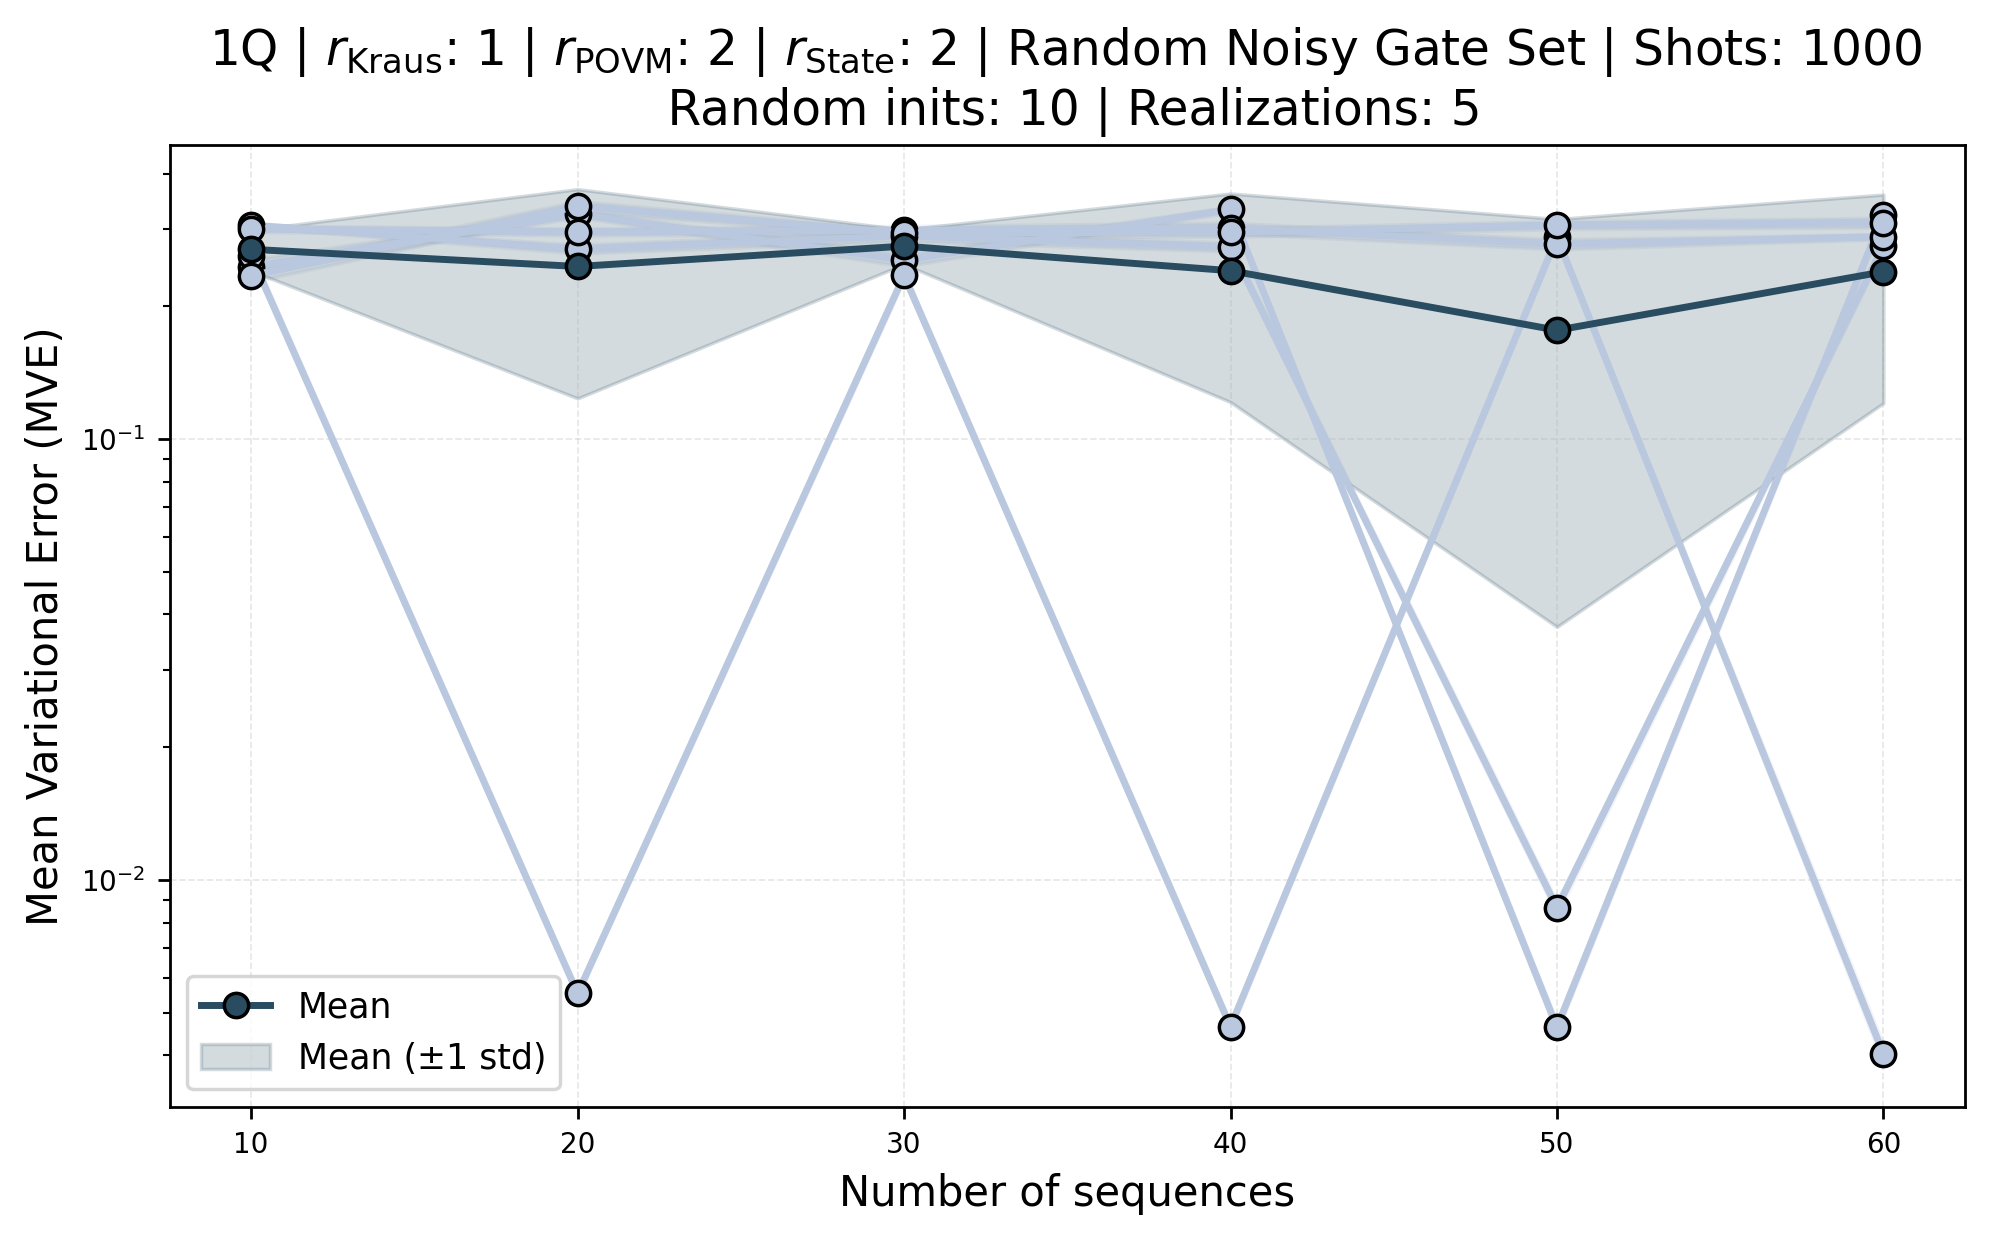

In [72]:
fig_mve_batched = plot_many_mean_std_vs_x(
    data=mve_combined_batched,
    title=title_init + f" \n Random inits: {num_max_random_inits} | Realizations: {num_realizations}",
    ylabel=f"Mean Variational Error (MVE)",
    use_log_scale="y",
    main_curve=mean_mve_results_combined_batched,
    main_curve_label="Mean",
)

## Debugging

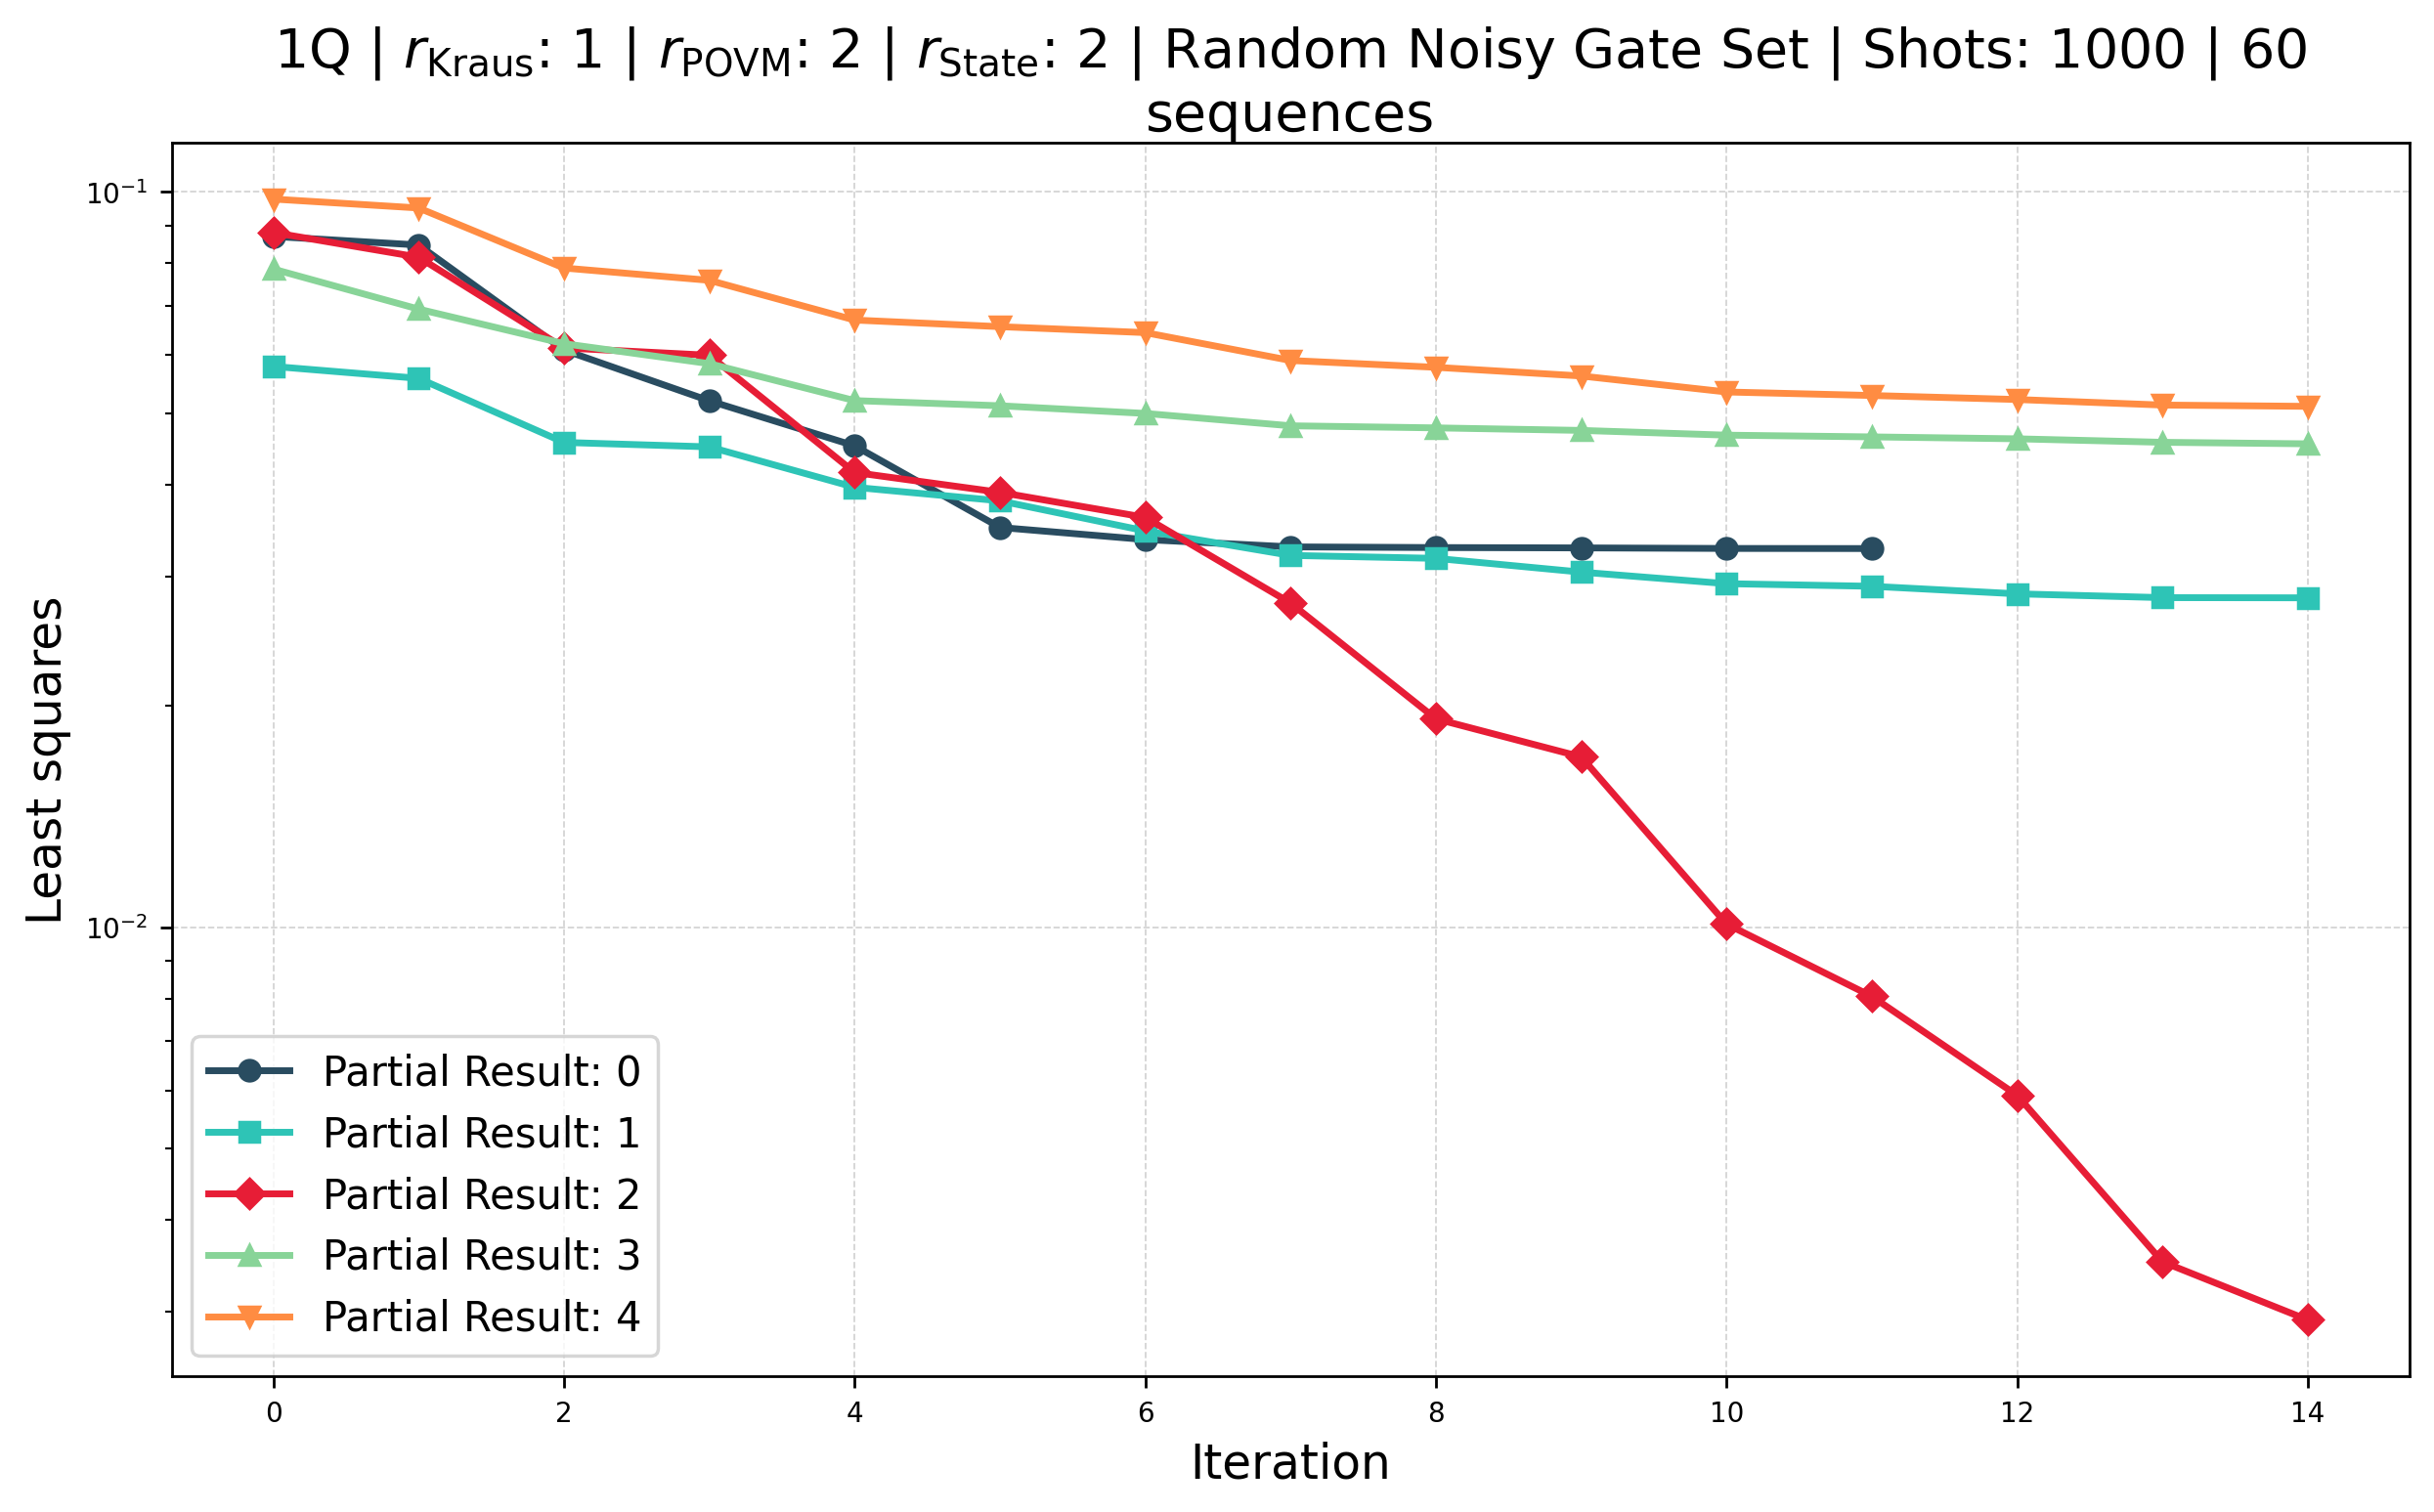

In [60]:
sequences_test = 60
result_test_partial = get_all_realizations_for_key(partial_results_medium, str(sequences_test))
result_test_final = get_all_realizations_for_key(final_results_medium, str(sequences_test))

costs_test = [res["cost_fn_history"]["main"] for res in result_test_partial] + [res["cost_fn_history"]["least_squares"] for res in result_test_final]

labels_test = [f"Partial Result: {i}" for i in range(len(result_test_partial))] + [f"Final Result: {i}" for i in range(len(result_test_final))]

partial_idx = len(result_test_partial)

plot_cost_function(costs_test[:partial_idx], title=title_init + f" | {sequences_test} sequences", labels=labels_test[:partial_idx], ylabel="Least squares")

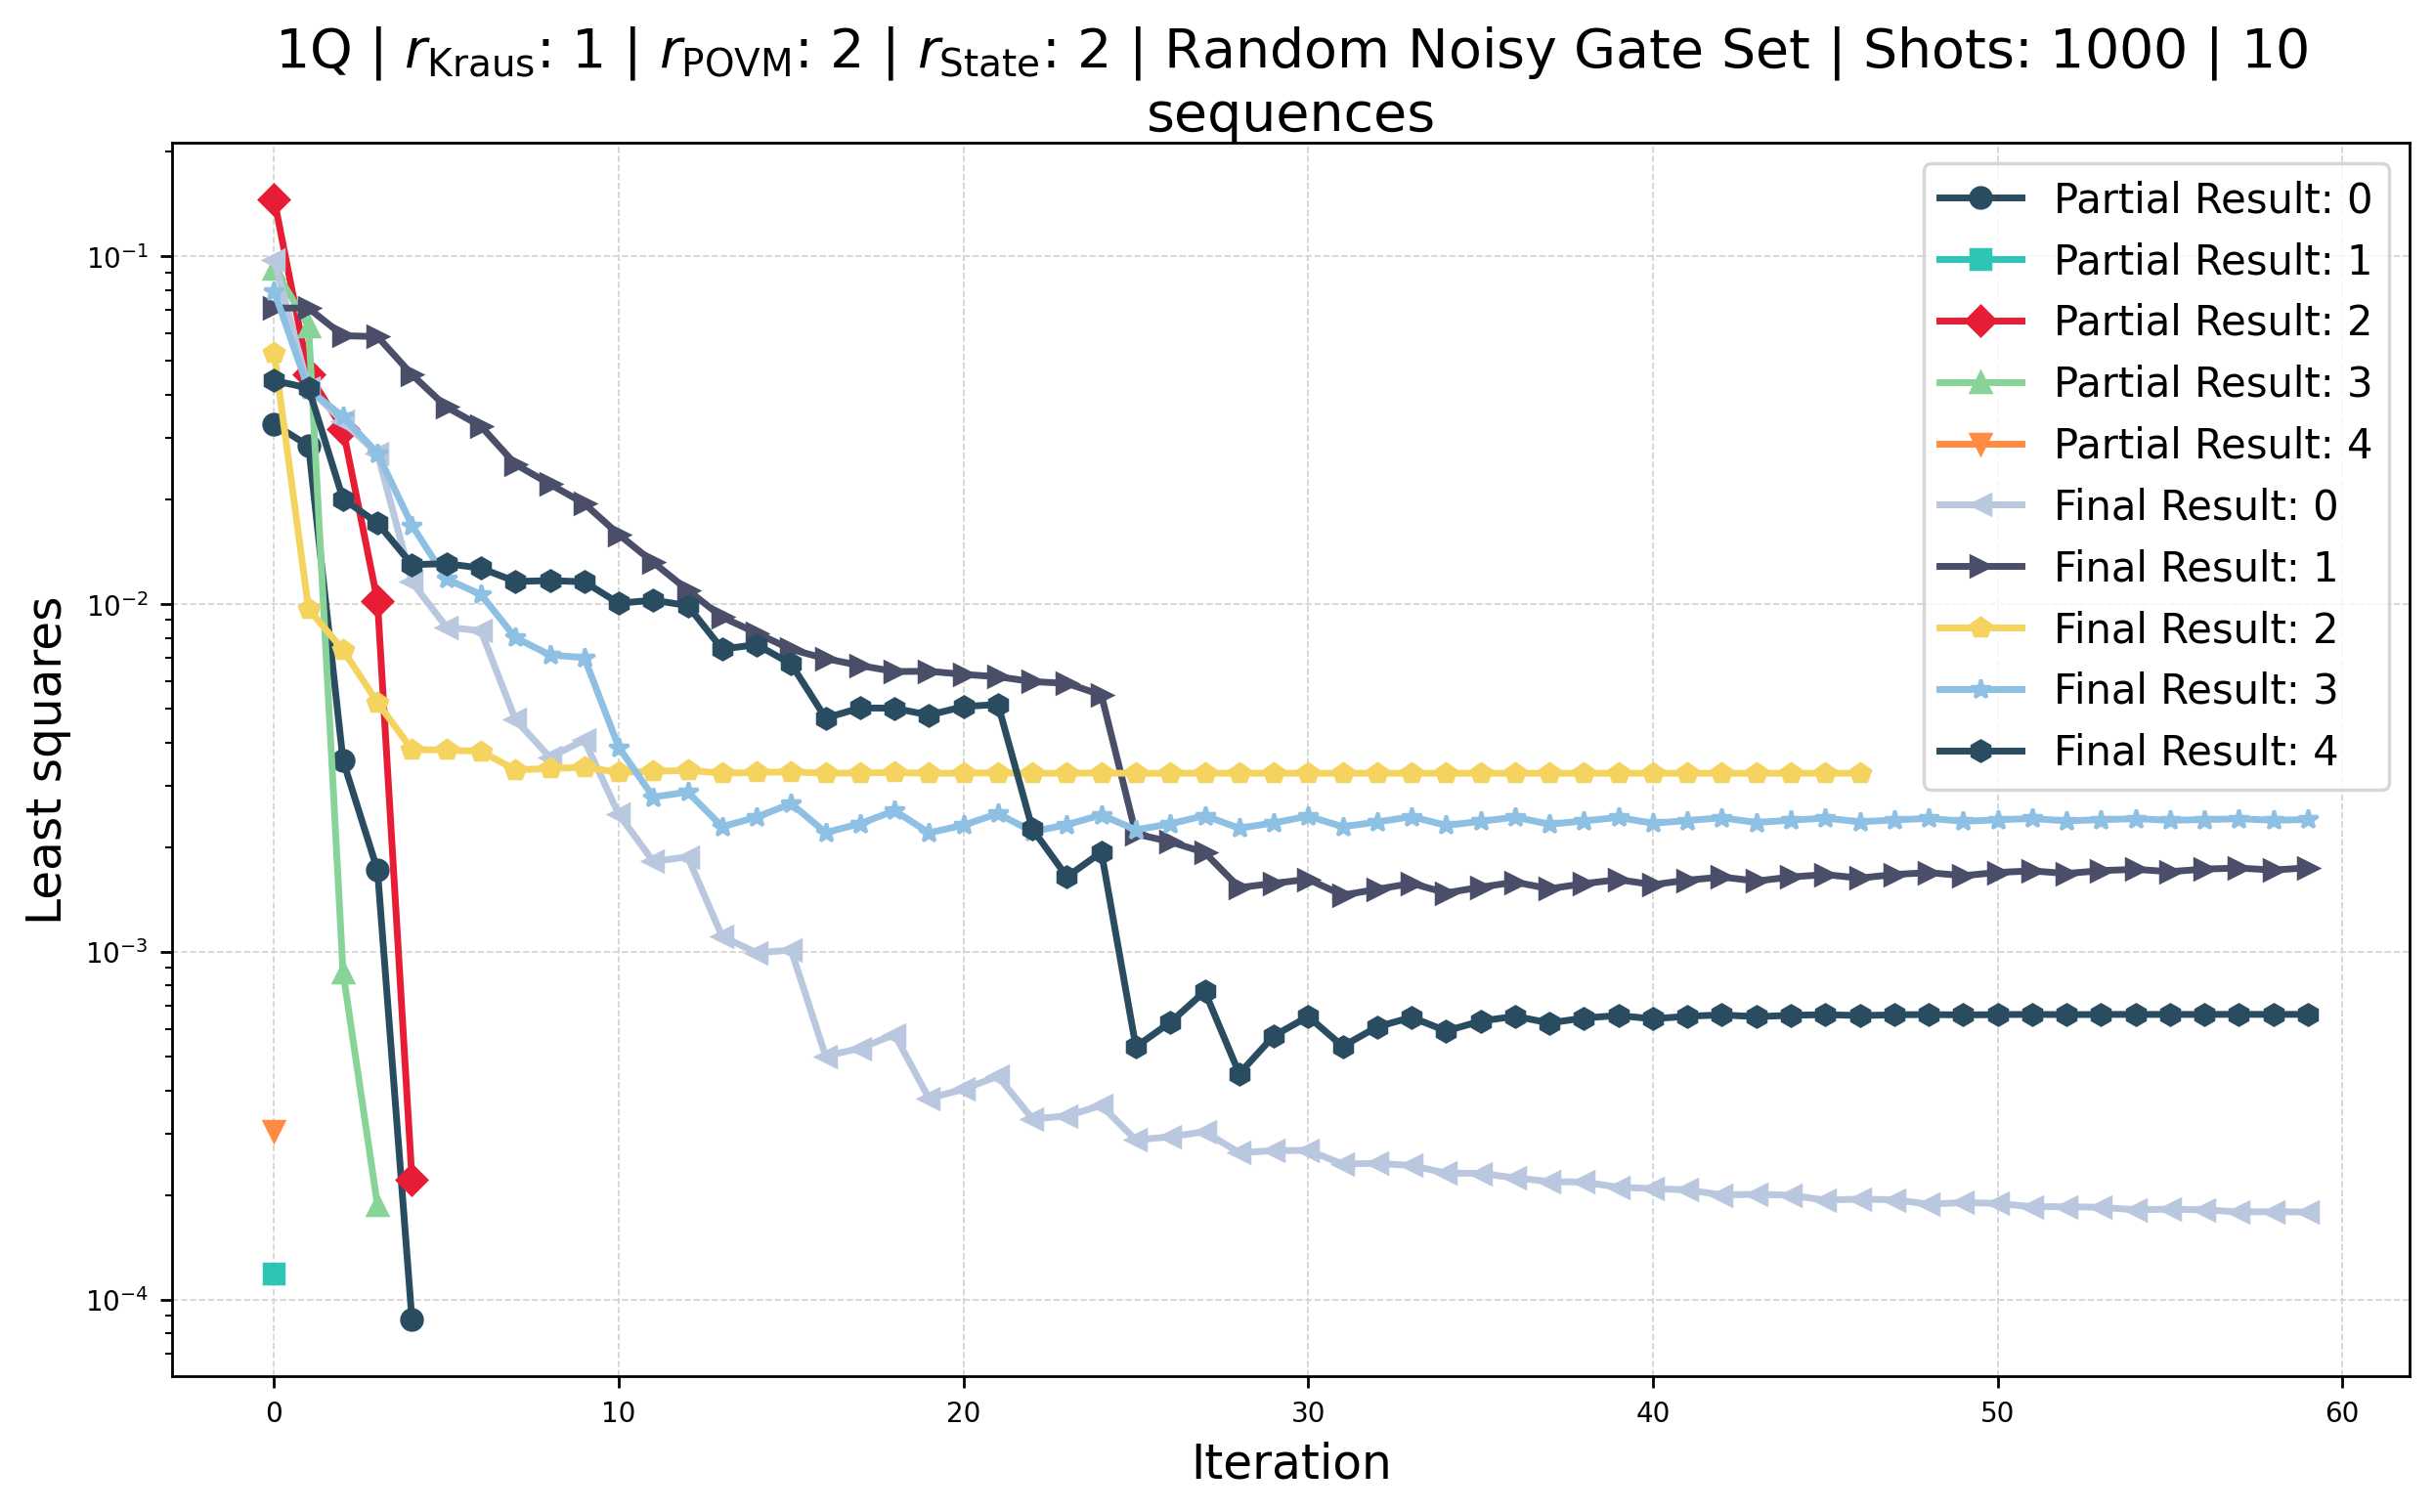

In [57]:
sequences_test = 10
result_test_partial = get_all_realizations_for_key(partial_results_small_batched, str(sequences_test))
result_test_final = get_all_realizations_for_key(final_results_small_batched, str(sequences_test))

costs_test = [res["cost_fn_history"]["main"] for res in result_test_partial] + [res["cost_fn_history"]["least_squares"] for res in result_test_final]

labels_test = [f"Partial Result: {i}" for i in range(len(result_test_partial))] + [f"Final Result: {i}" for i in range(len(result_test_final))]

partial_idx = len(result_test_partial)

plot_cost_function(costs_test[:], title=title_init + f" | {sequences_test} sequences", labels=labels_test[:], ylabel="Least squares")

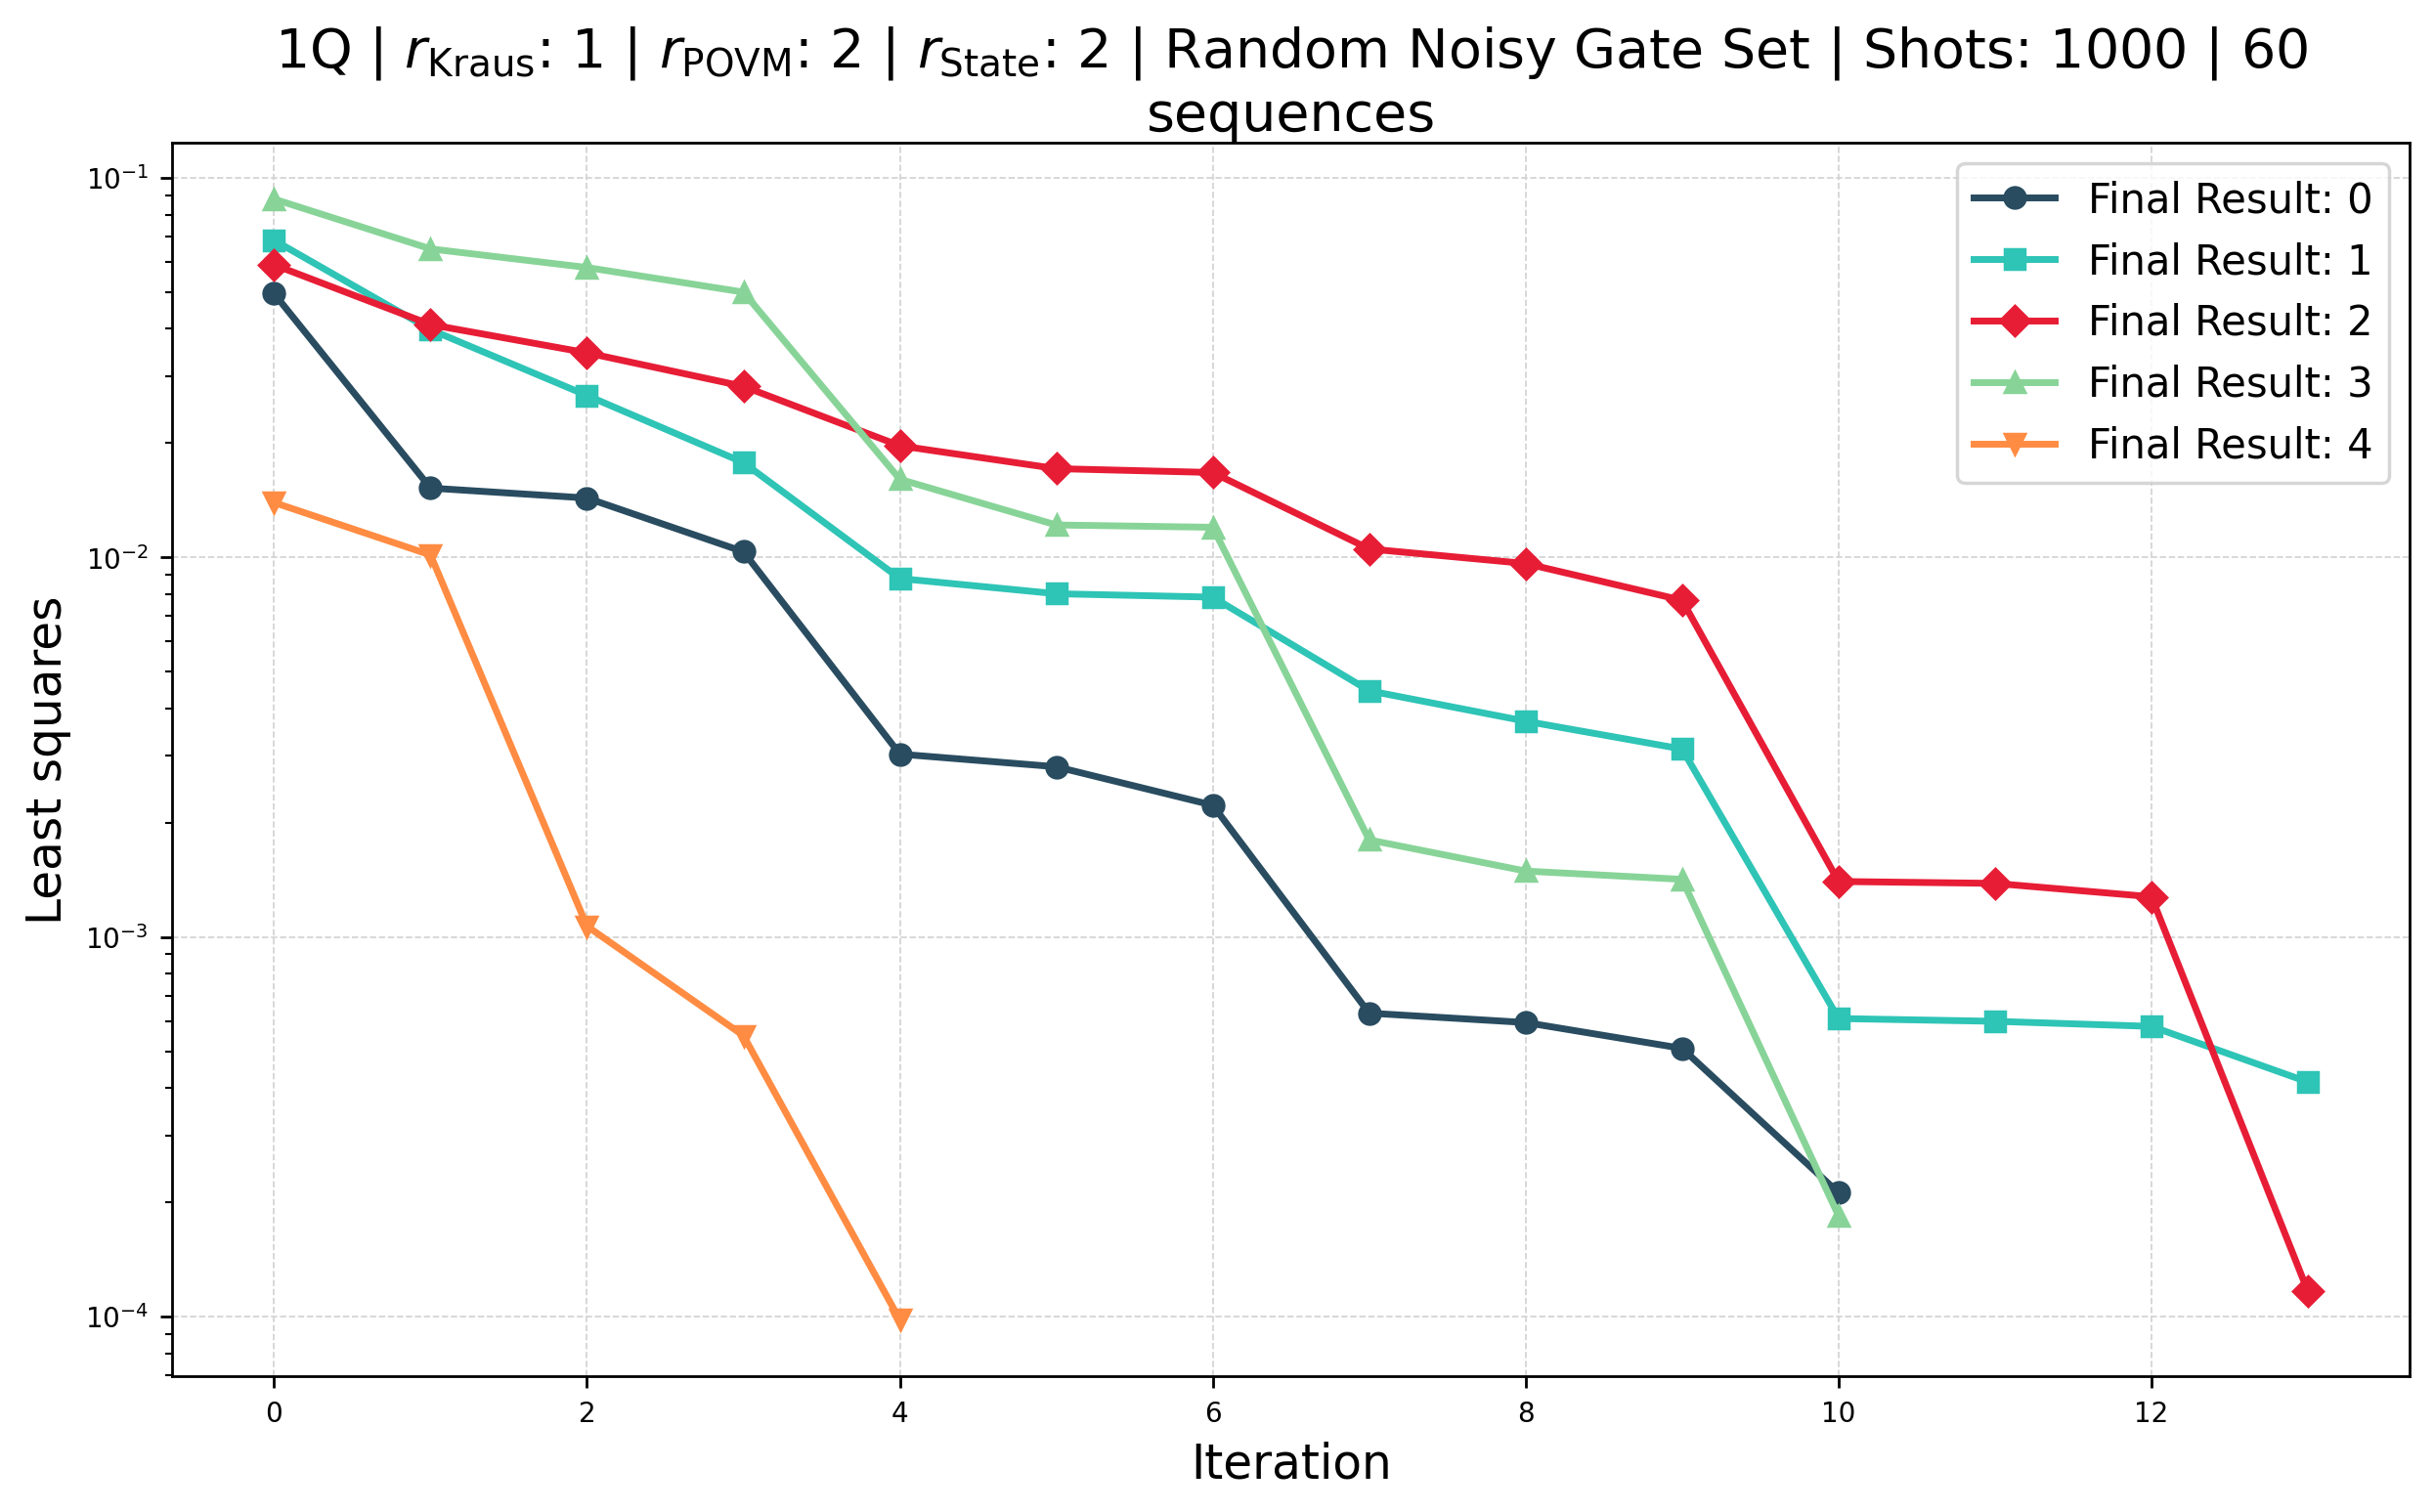

In [82]:
result_test = get_all_realizations_for_key(partial_results_small_batched, str(20))
costs_test = [res["cost_fn_history"]["main"] for res in result_test]
labels_test = [f"Final Result: {i}" for i in range(len(costs_test))]
plot_cost_function(costs_test[:], title=title_init + f" | {sequences_test} sequences", labels=labels_test[:], ylabel="Least squares")

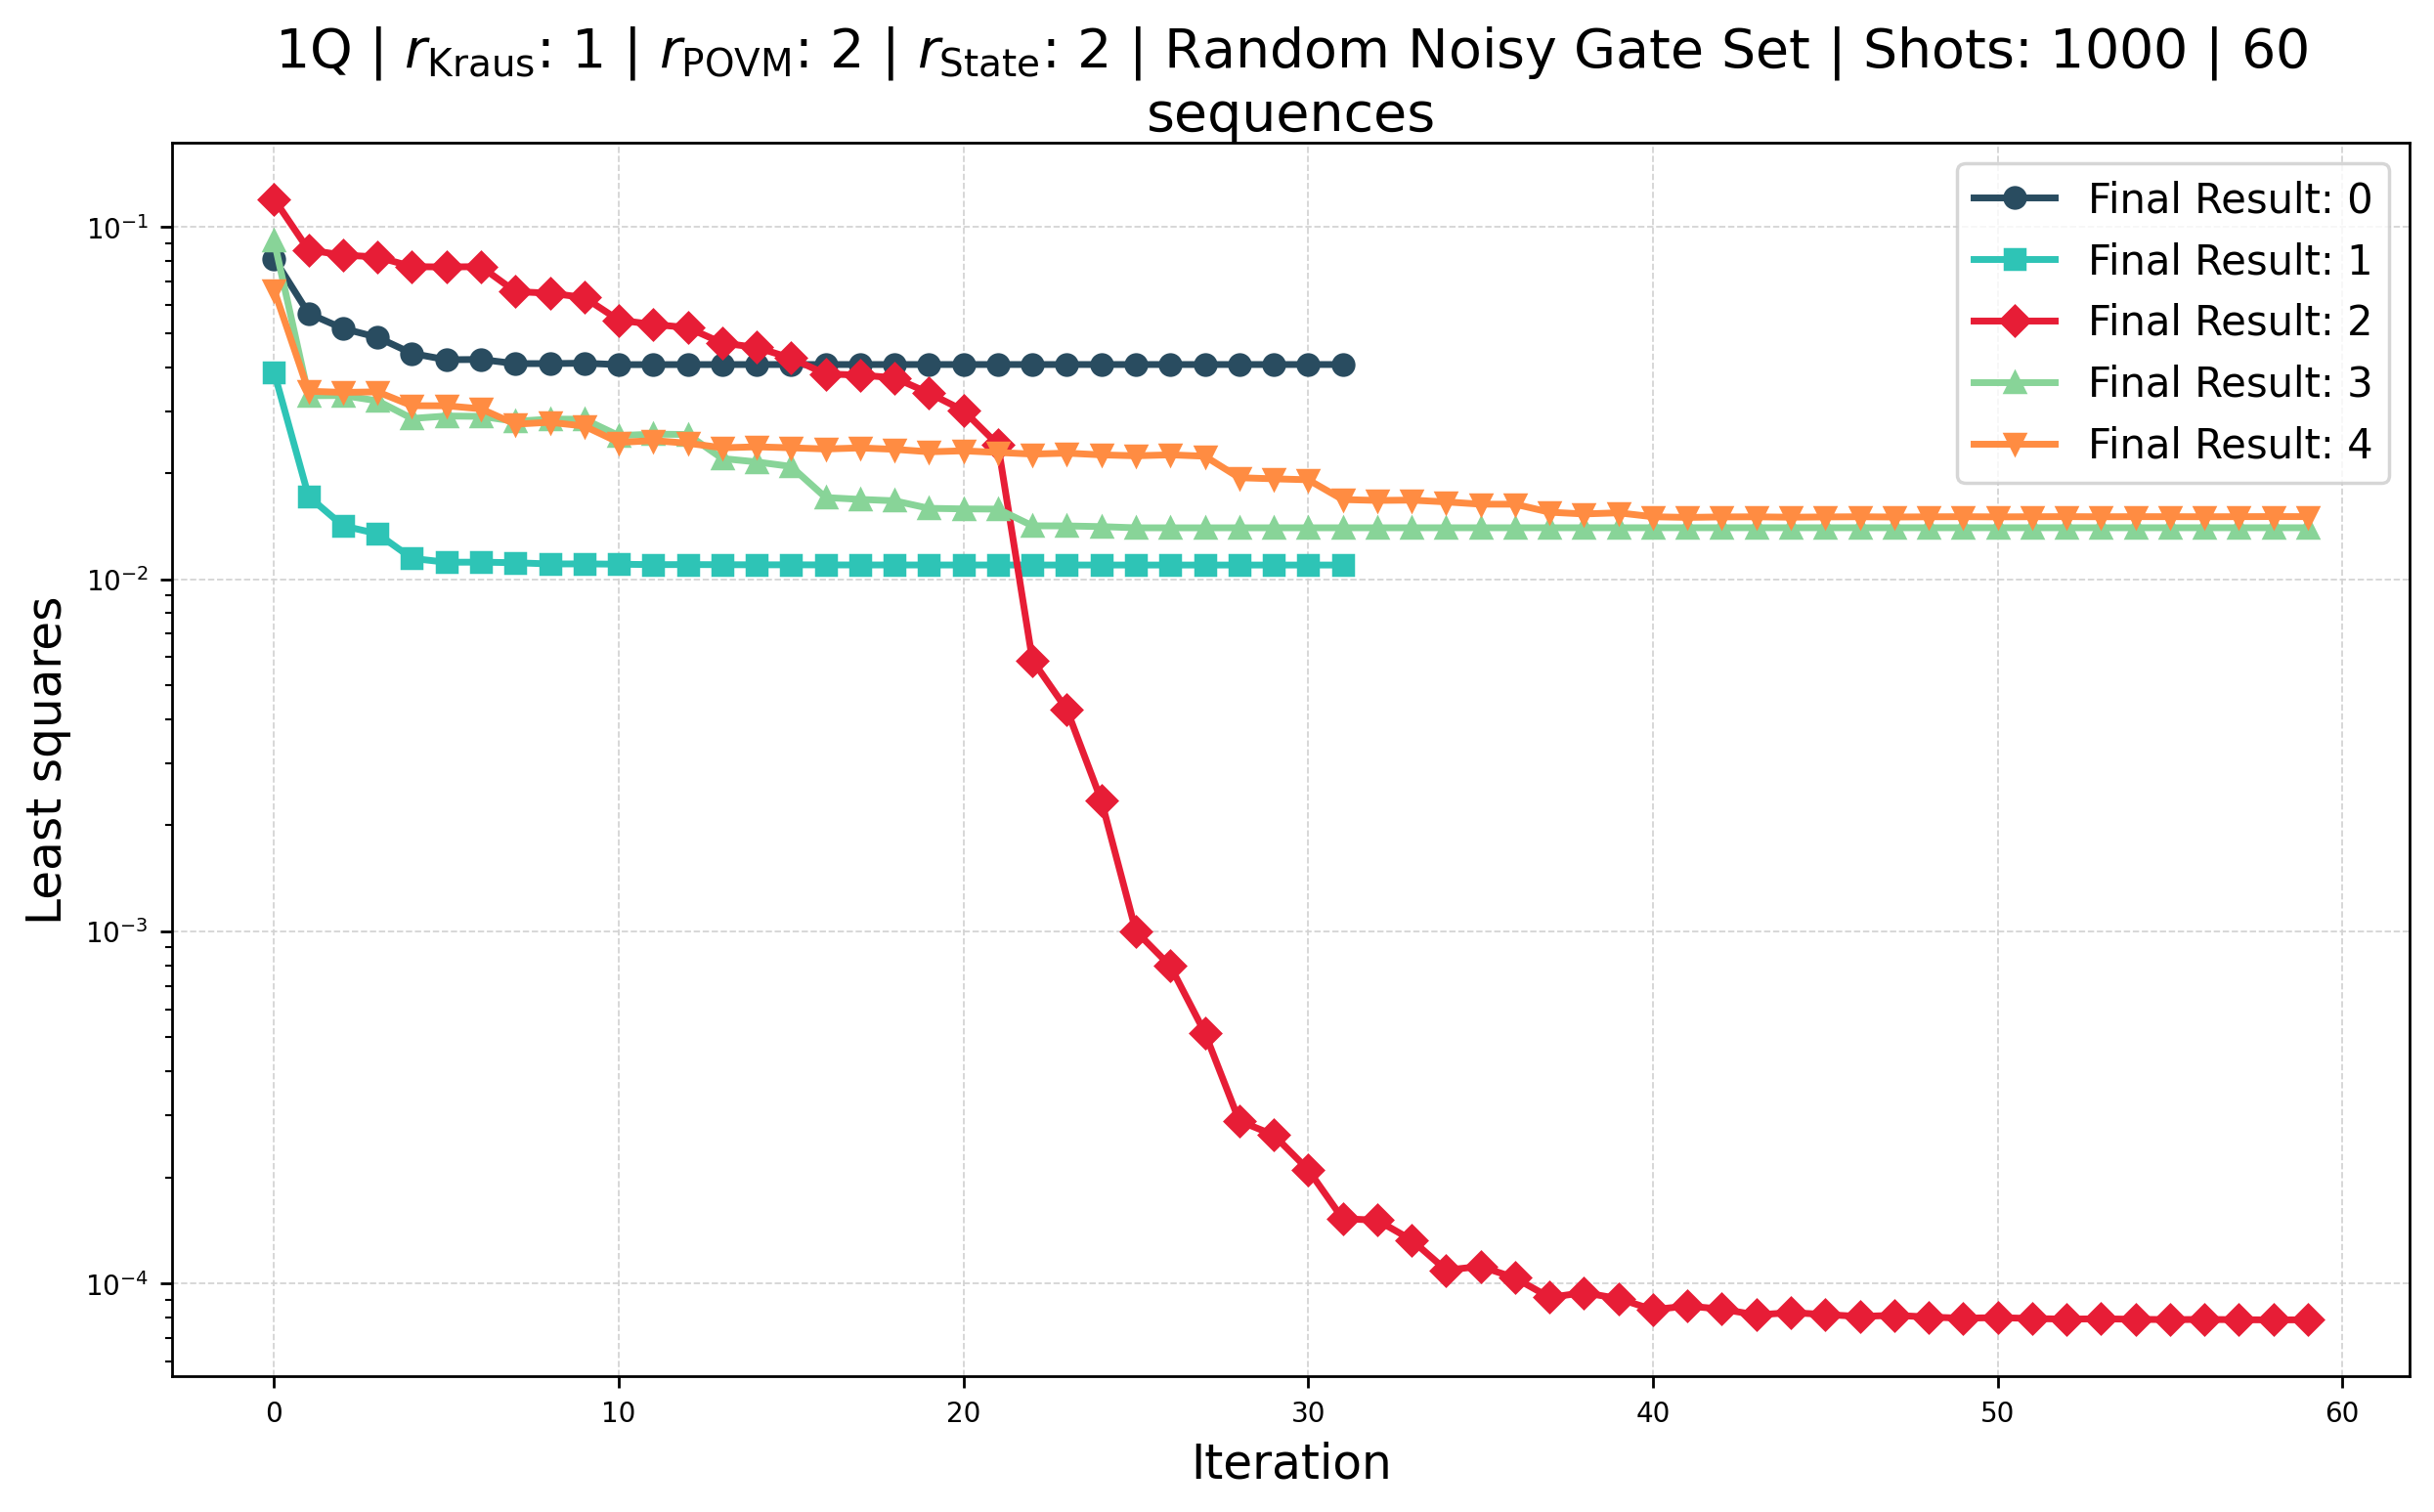

In [83]:
result_test = get_all_realizations_for_key(final_results_small_batched, str(20))
costs_test = [res["cost_fn_history"]["least_squares"] for res in result_test]
labels_test = [f"Final Result: {i}" for i in range(len(costs_test))]
plot_cost_function(costs_test[:], title=title_init + f" | {sequences_test} sequences", labels=labels_test[:], ylabel="Least squares")

In [127]:
partial_results_small_batched[0]["20"]["times"]

{'optimization_time': 10.994117975234985}

In [126]:
final_results_small_batched[0]["20"]["times"]

{'optimization_time': 33.473893880844116, 'gauge_time': 0.05036592483520508}

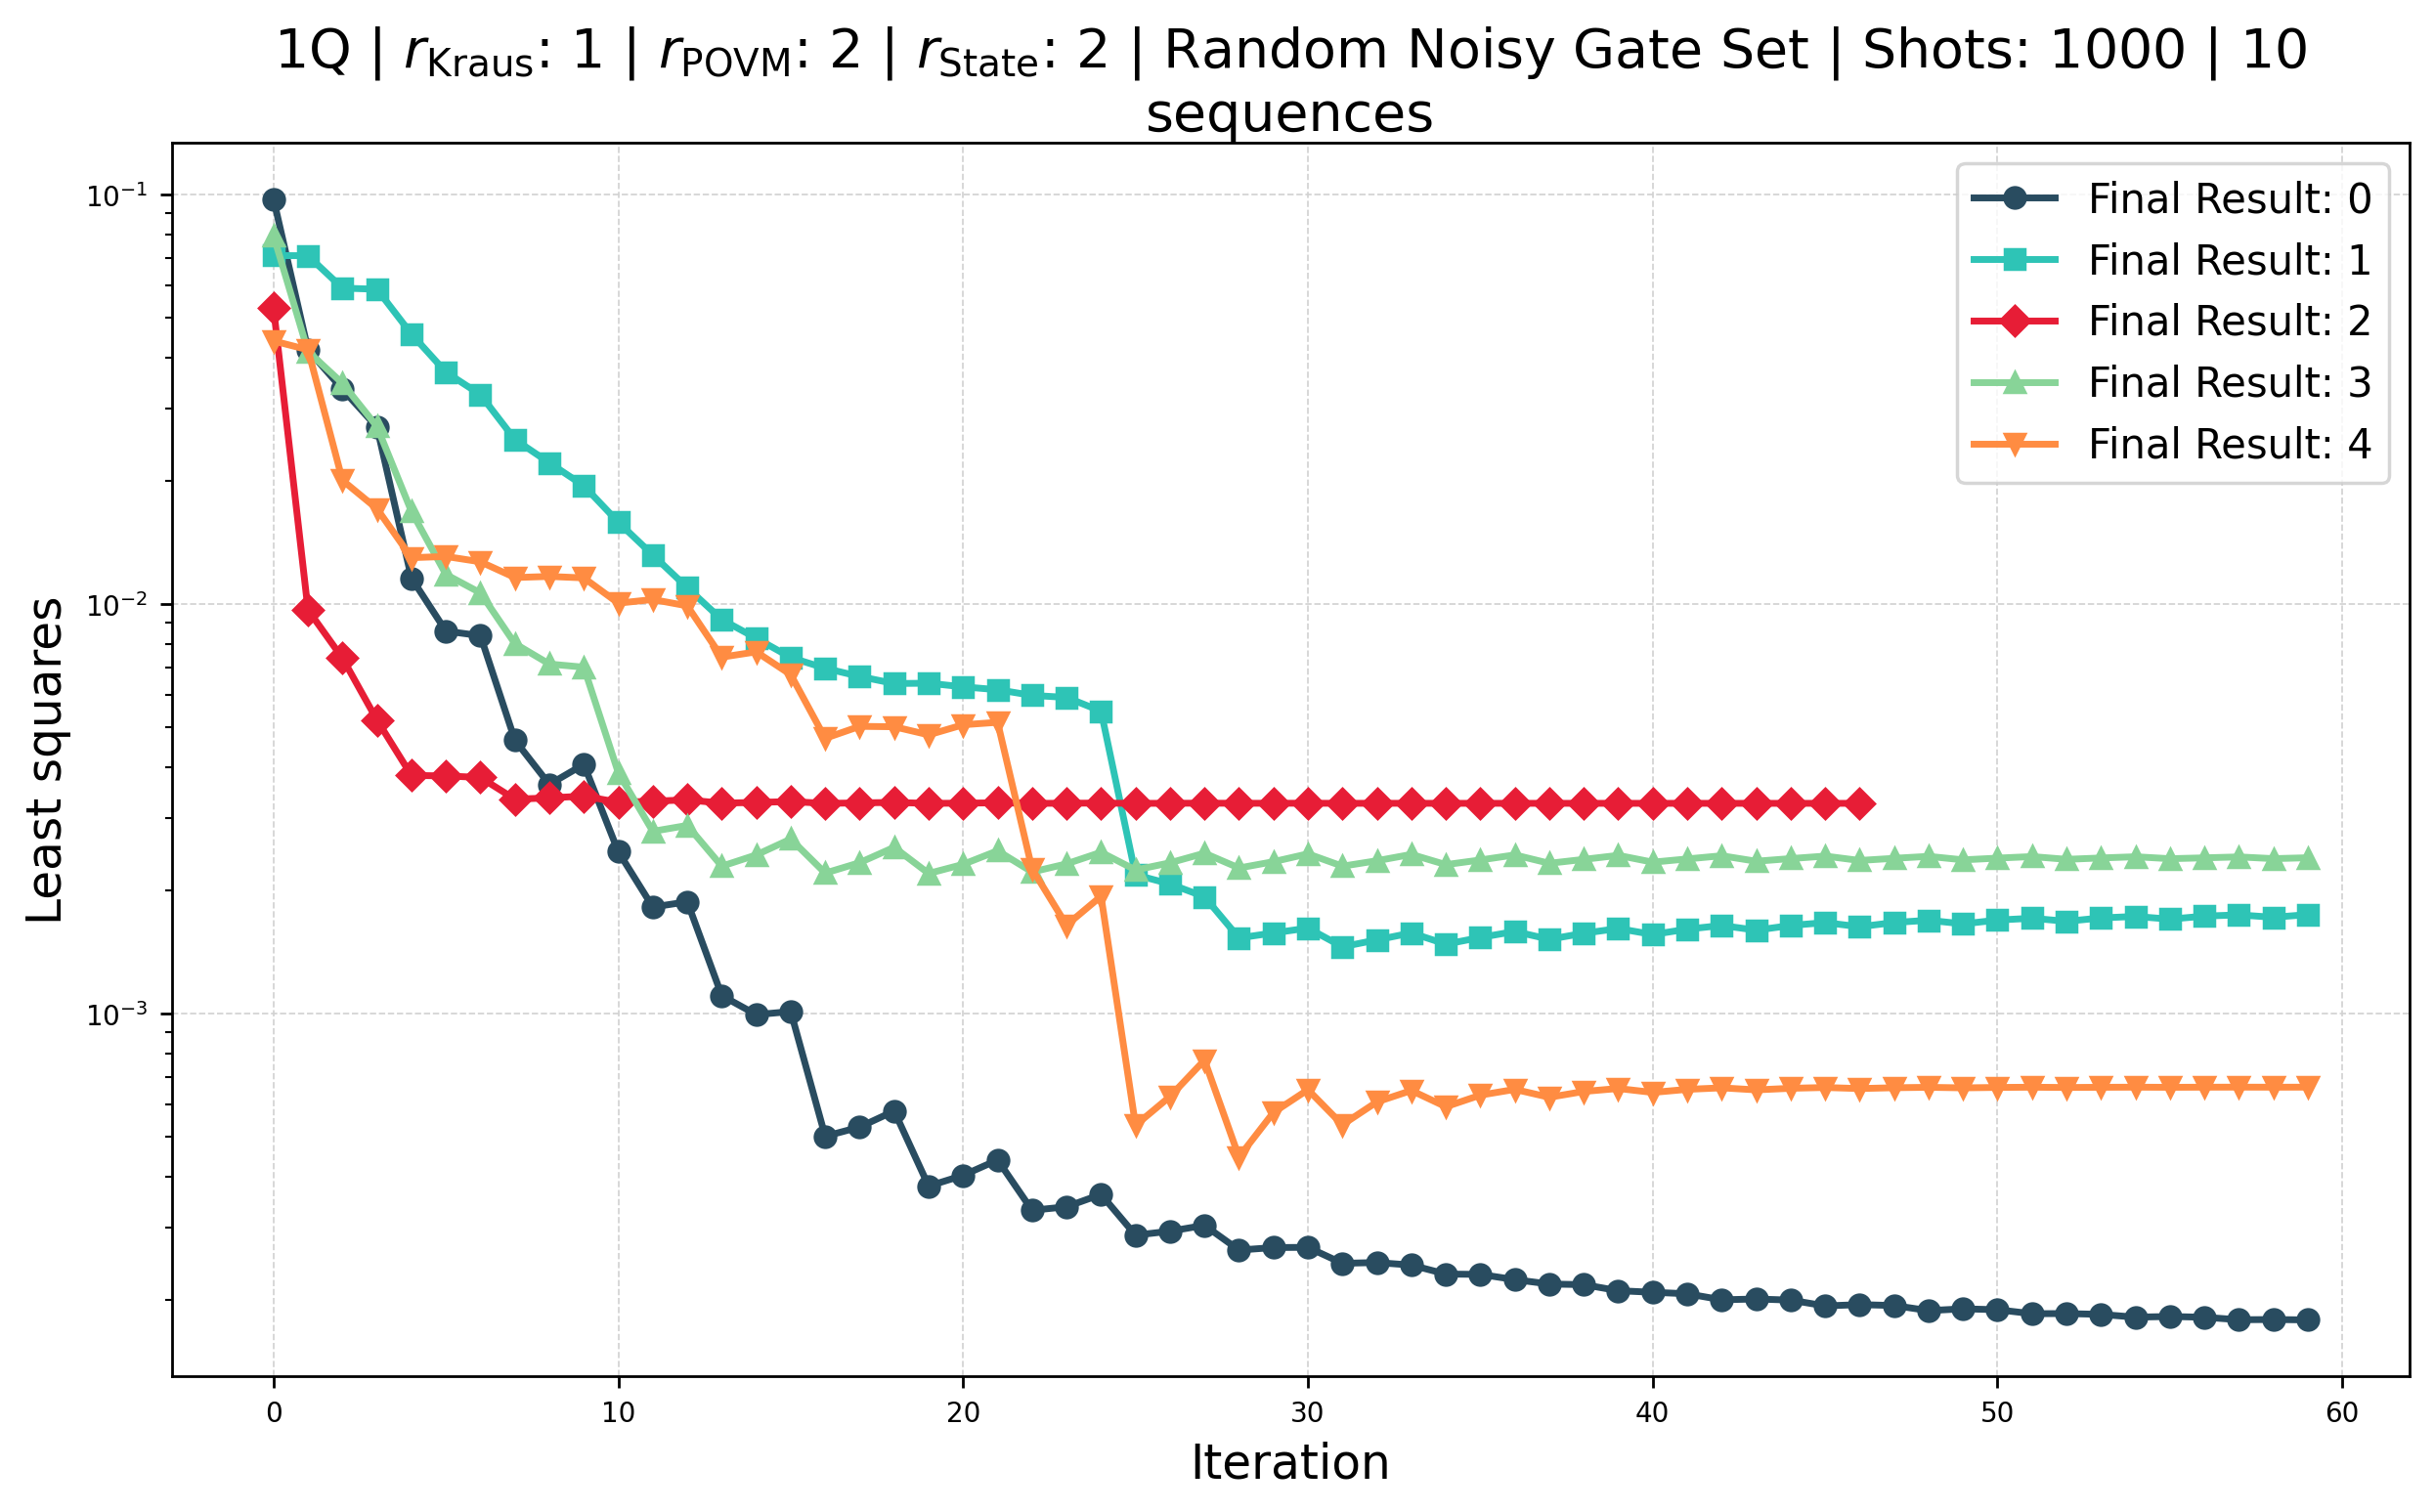

In [42]:
result_test = get_all_realizations_for_key(final_results_small_batched, str(sequences_test))
costs_test = [res["cost_fn_history"]["least_squares"] for res in result_test]
labels_test = [f"Final Result: {i}" for i in range(len(costs_test))]
plot_cost_function(costs_test[:], title=title_init + f" | {sequences_test} sequences", labels=labels_test[:], ylabel="Least squares")

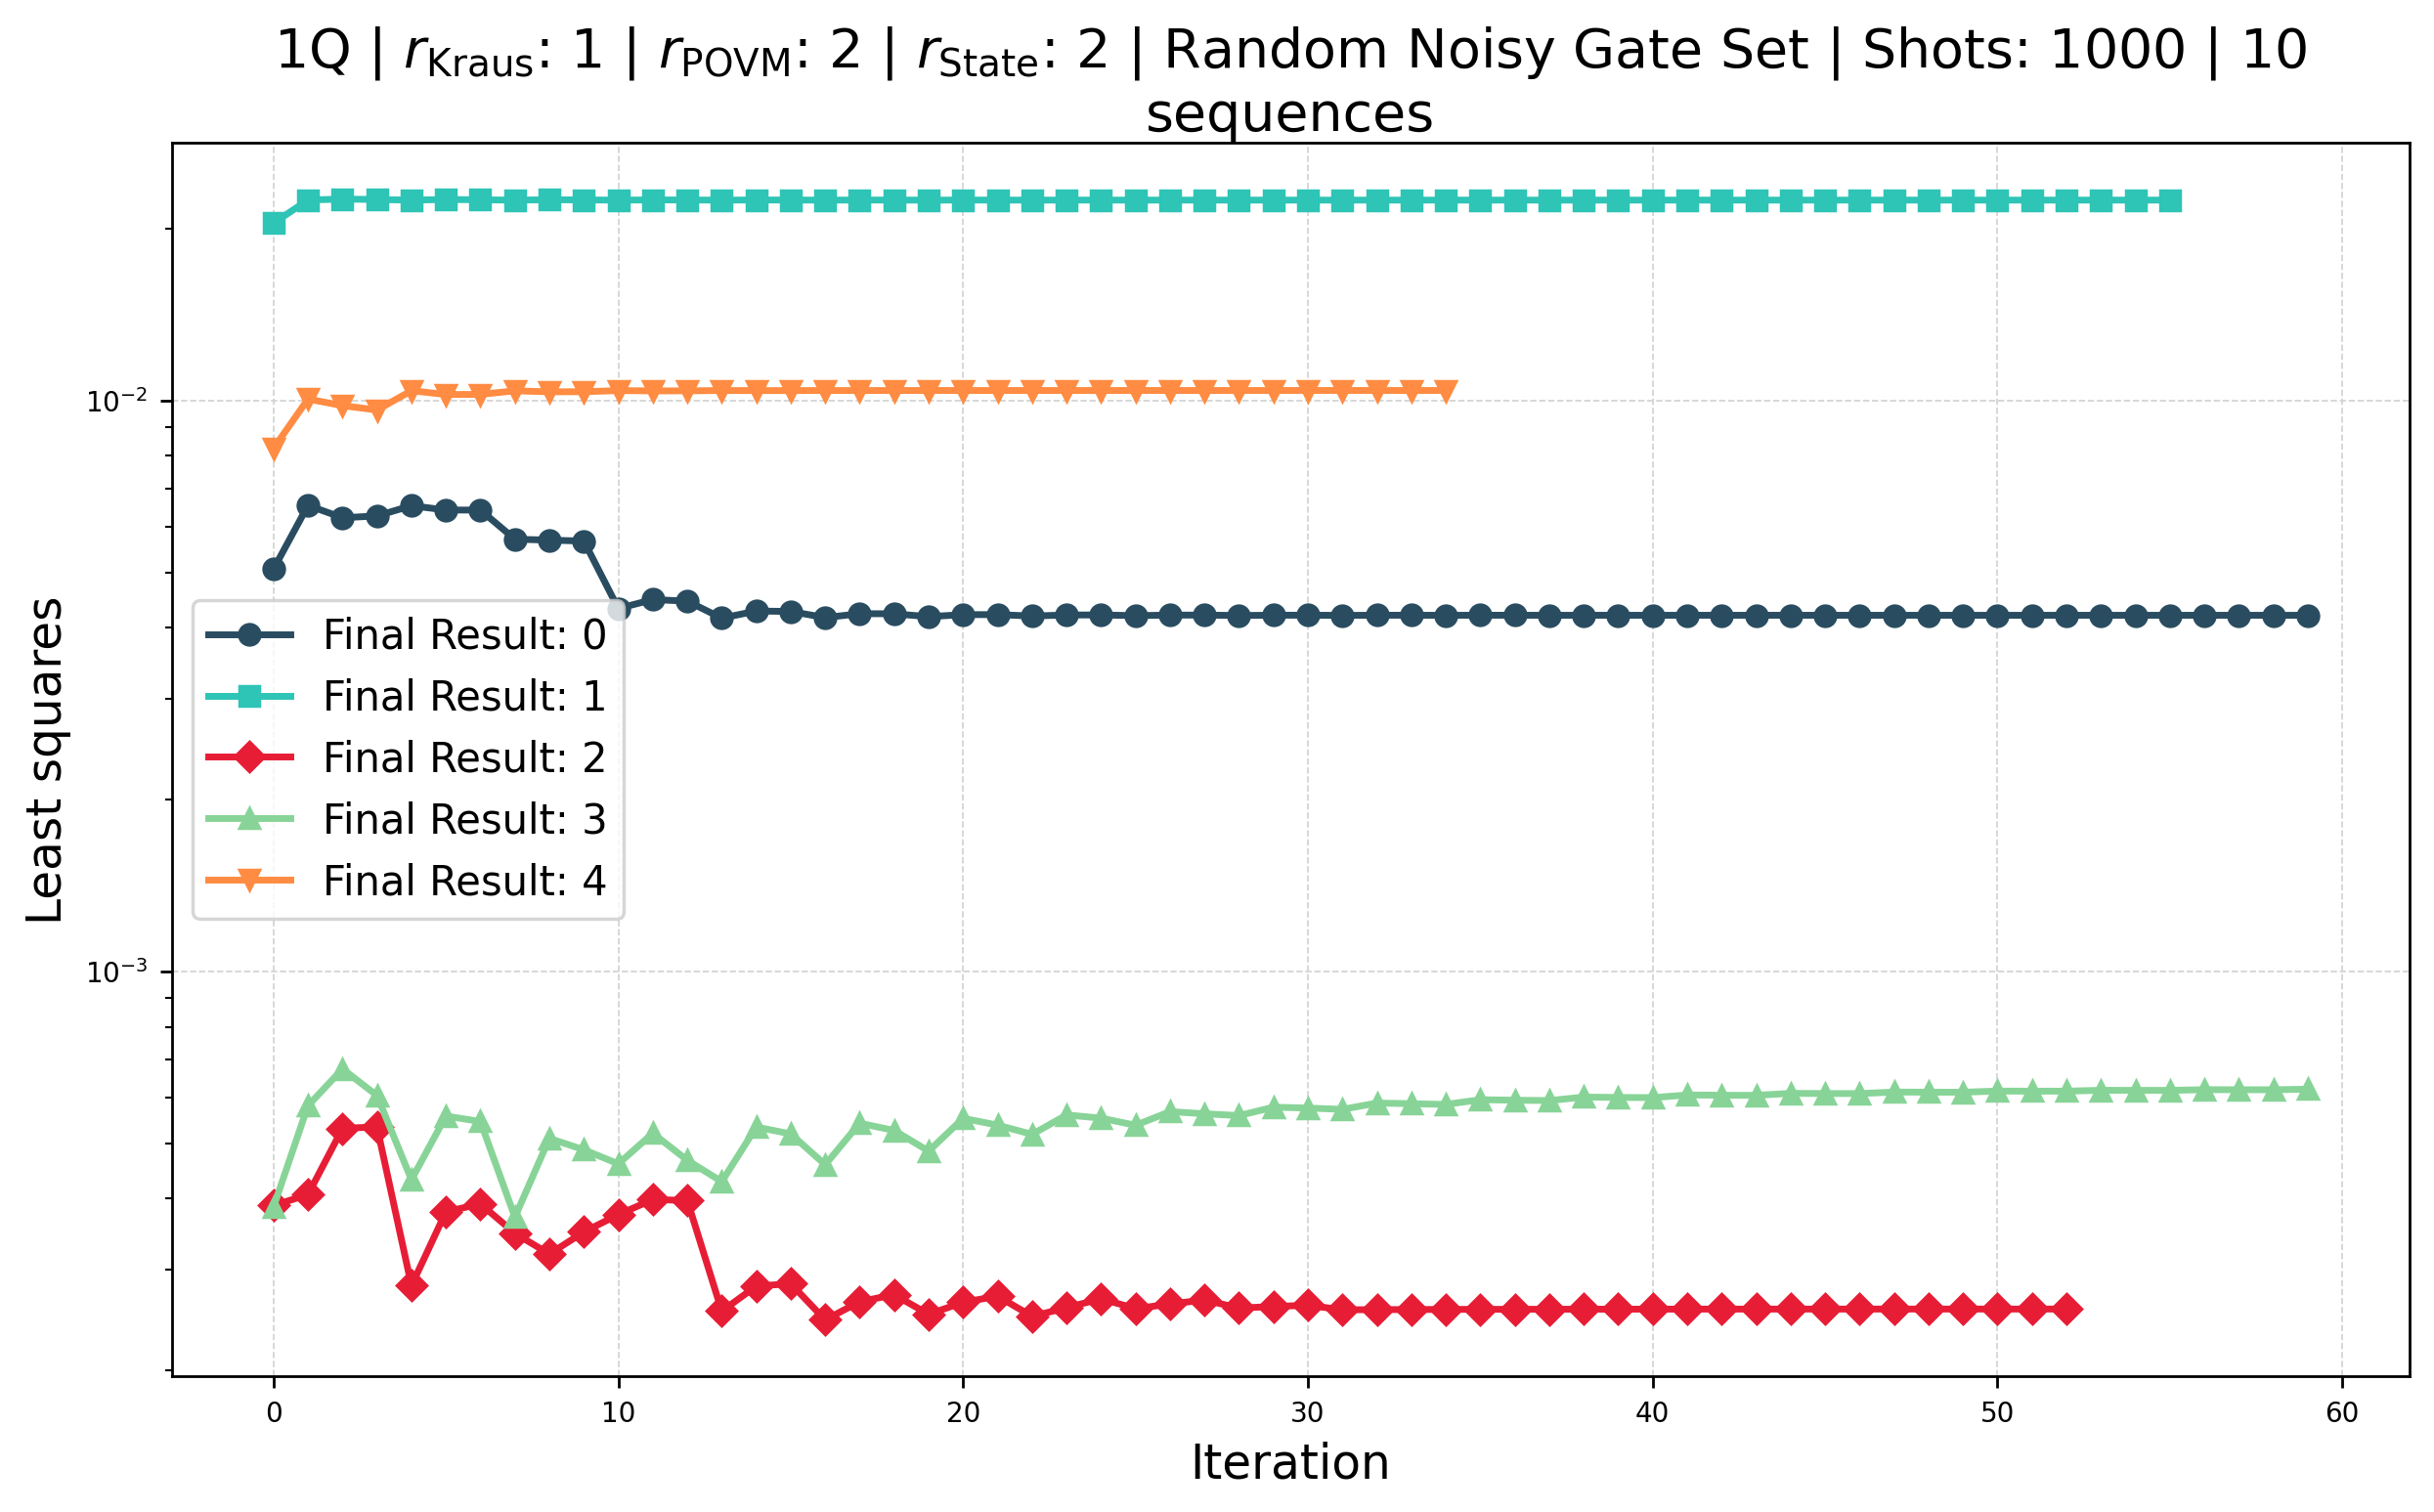

In [43]:
result_test = get_all_realizations_for_key(final_results_small, str(sequences_test))
costs_test = [res["cost_fn_history"]["least_squares"] for res in result_test]
labels_test = [f"Final Result: {i}" for i in range(len(costs_test))]
plot_cost_function(costs_test[:], title=title_init + f" | {sequences_test} sequences", labels=labels_test[:], ylabel="Least squares")

# Save data

In [347]:
folder = "data/random_init_vs_sequences"

save_optimization_result(final_results_small, f"{folder}/final_results_small.pkl")
save_optimization_result(final_results_medium, f"{folder}/final_results_medium.pkl")
save_optimization_result(final_results_large, f"{folder}/final_results_large.pkl")
save_optimization_result(final_results_large_large, f"{folder}/final_results_large_large.pkl")
save_optimization_result(final_results_xl, f"{folder}/final_results_xl.pkl")
save_optimization_result(final_result_70_extra, f"{folder}/final_result_70_extra.pkl")

Optimization result saved to data/random_init_vs_sequences/final_results_small.pkl
Optimization result saved to data/random_init_vs_sequences/final_results_medium.pkl
Optimization result saved to data/random_init_vs_sequences/final_results_large.pkl
Optimization result saved to data/random_init_vs_sequences/final_results_large_large.pkl
Optimization result saved to data/random_init_vs_sequences/final_results_xl.pkl
Optimization result saved to data/random_init_vs_sequences/final_result_70_extra.pkl


In [348]:
save_variational_errors(error_results=mve_combined, filename=f"{folder}/mve_combined.json")
save_variational_errors(error_results=mve_combined_ammended, filename=f"{folder}/mve_combined_ammended.json")

Variational errors saved to data/random_init_vs_sequences/mve_combined.json
Variational errors saved to data/random_init_vs_sequences/mve_combined_ammended.json
